In [67]:
from google.colab import drive, files
drive.mount('/content/gdrive/')

import os
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis


In [68]:
import pandas as pd
data = pd.read_csv("AMZN_BERT_SCORE_READY_FOR_TRAINING.csv")
seed = 412
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,Bert_Label,Bert_Score
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",neutral,0.666194
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",negative,0.911996
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",negative,0.434760
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",positive,0.639022
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",positive,0.608427


In [69]:
data['Bert_Label'] = data['Bert_Label'].replace({'neutral':0.5, 'negative':0, 'positive':1})
data.head()

<ipython-input-69-ab3eb056249a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Bert_Label'] = data['Bert_Label'].replace({'neutral':0.5, 'negative':0, 'positive':1})


,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,Bert_Label,Bert_Score
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.5,0.666194
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.0,0.911996
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.0,0.434760
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",1.0,0.639022
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",1.0,0.608427


In [70]:
days = 60

In [71]:
amzn_data = data[['Close','Bert_Score']]
amzn_data.head()

,Close,Bert_Score
0,159.524506,0.666194
1,161.195496,0.911996
2,157.597000,0.434760
3,158.073502,0.639022
4,161.145004,0.608427


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450562   0.66619354]
 [161.19549561   0.91199577]
 [157.59700012   0.4347603 ]
 ...
 [188.71000671   0.50964153]
 [192.08000183   0.90277892]
 [193.05999756   0.8153981 ]]


In [72]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [73]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450562   0.66619354]
 [161.19549561   0.91199577]
 [157.59700012   0.4347603 ]
 ...
 [180.83000183   0.83806461]
 [179.8500061    0.81723231]
 [182.5          0.80950516]]


<class 'numpy.ndarray'>


In [74]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.51476589]
 [0.67164914 0.90471829]
 [0.64119987 0.14760914]
 ...
 [0.83778983 0.78743036]
 [0.82949743 0.75438101]
 [0.8519208  0.74212229]]


(785, 2)


In [75]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 2)


In [76]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 2)
Test inputs with a reshape : (257, 2)
Test inputs after transformed : (257, 2)


In [77]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [78]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 2)
(725, 1)


In [79]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [80]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 2)
725
60


In [81]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 60, 2)
(197, 60, 2)


In [82]:
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Models


In [83]:
import joblib
model = joblib.load('BERT_Model1')

In [84]:
predictions = model.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step


In [85]:
rmse1 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse1)

3.018520385586422


<ipython-input-86-36533a0e113b>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_len]
<ipython-input-86-36533a0e113b>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_len:]
<ipython-input-86-36533a0e113b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

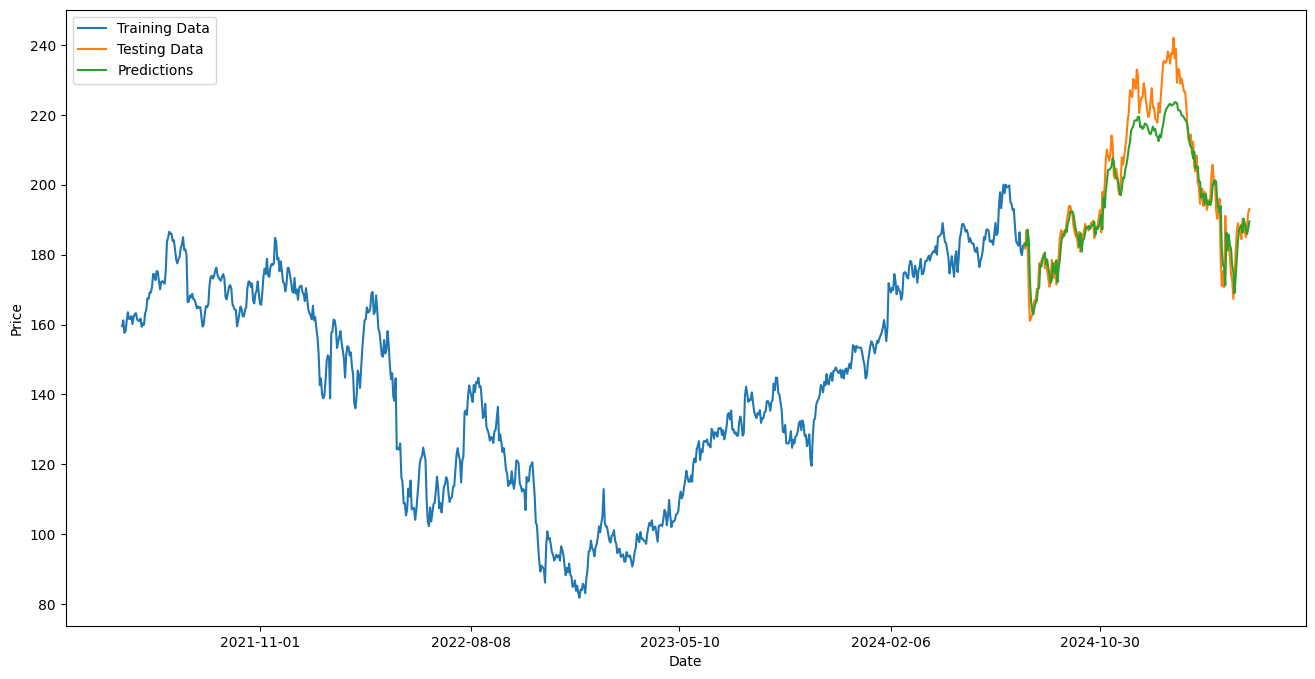

In [86]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
dates = data['Date']
train = amzn_data[:amzn_len]
train['Date'] = dates[:amzn_len]
testing = amzn_data[amzn_len:]
testing['Date'] = dates[amzn_len:]
testing['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train['Date'],train['Close'], label = "Training Data")
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [87]:
testing.head()

,Close,Bert_Score,Date,Predictions
785,183.199997,0.913264,2024-07-29,182.699240
786,181.710007,0.970124,2024-07-30,183.221326
787,186.979996,0.934309,2024-07-31,182.502492
788,184.070007,0.951828,2024-08-01,187.131965
789,167.899994,0.930361,2024-08-02,184.216006


Model Accuracy: 52.04%


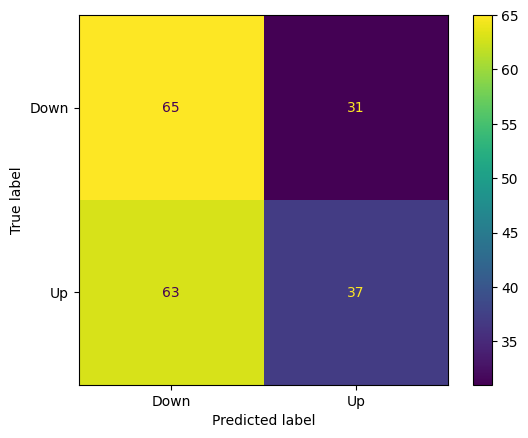

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
actual_next_day = testing['Close'].shift(-1).values
actual_today = testing['Close'].values
predicted_next_day = np.append(predictions[1:], predictions[-1])

actual_movement = (actual_next_day > actual_today).astype(int)
predicted_movement = (predicted_next_day > actual_today).astype(int)
actual_movement = actual_movement[:-1]
predicted_movement = predicted_movement[:-1]
cm = confusion_matrix(actual_movement, predicted_movement)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
accuracy = (cm[0][0] + cm[1][1]) / np.sum(cm)
print(f"Model Accuracy: {accuracy:.2%}")
disp.plot()

In [93]:
p_movement = (predicted_next_day > actual_today)
points_up = []
points_down = []
x_up = []
x_down = []
for i in range(len(predictions)):
  if p_movement[i] == True:
    points_up.append(predictions[i])
    x_up.append(i)
  else:
    points_down.append(predictions[i])
    x_down.append(i)

print(points_up)
print(points_down)
print(x_up)
print(x_down)

[np.float64(182.6992398673574), np.float64(183.22132571775228), np.float64(182.50249175440922), np.float64(187.13196477904967), np.float64(184.21600573397745), np.float64(172.54368144097862), np.float64(166.61606252155798), np.float64(163.98947415708835), np.float64(170.16379778309965), np.float64(176.5805503610004), np.float64(179.03030421802487), np.float64(179.44597519812123), np.float64(180.58414306156828), np.float64(177.22244187195247), np.float64(178.61202692946154), np.float64(176.12516487512903), np.float64(174.38970859589972), np.float64(172.0035416213923), np.float64(175.55617956048263), np.float64(174.67366942541412), np.float64(178.365082724255), np.float64(172.05551282103897), np.float64(185.8202026835488), np.float64(185.4717251533616), np.float64(192.31314399760822), np.float64(191.37268224157287), np.float64(188.71994626351034), np.float64(187.19982037219097), np.float64(185.6482849418062), np.float64(184.98848738727838), np.float64(186.10154311644237), np.float64(180.

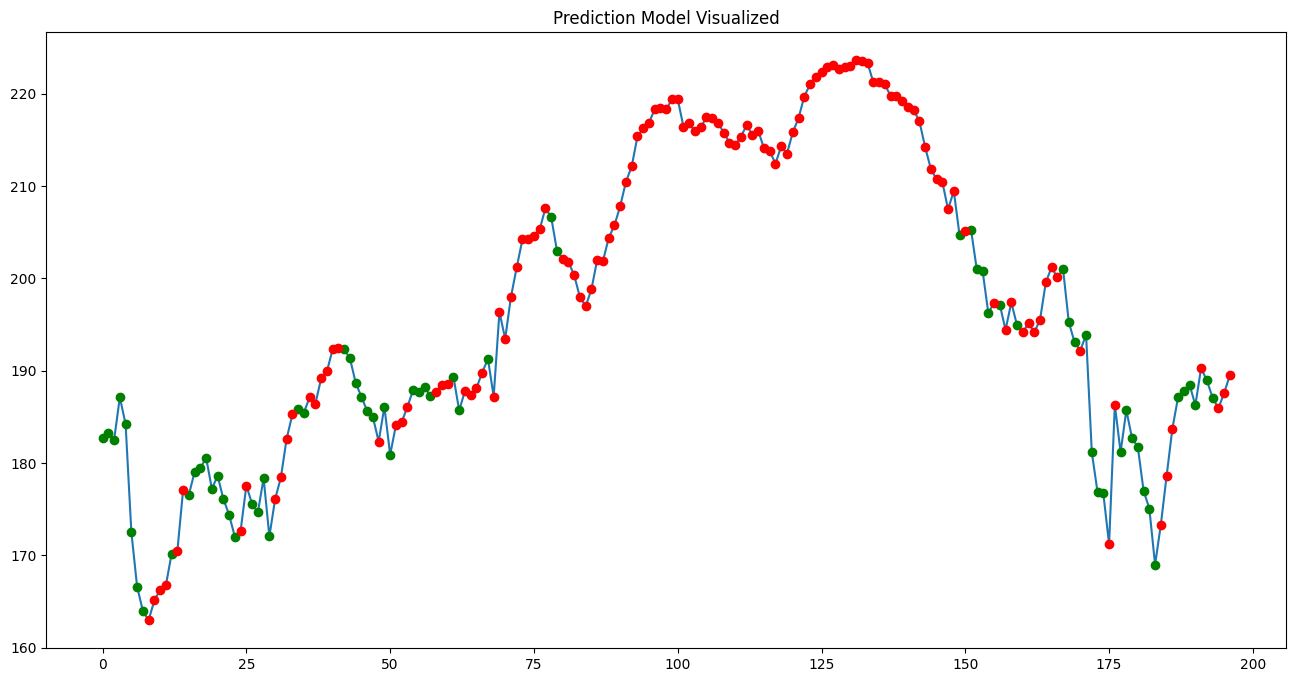

In [94]:
plt.figure(figsize=(16,8))
plt.title("Prediction Model Visualized")
plt.plot(predictions, label ="Predicted Price")
plt.plot(x_up, points_up , 'go',label = 'Up Prediction')
plt.plot(x_down, points_down, 'ro', label ="Down Prediction")